# YOLO Key Commands<br>
**Train**: model.train(data='data.yaml', epochs=100)

**Predict**: results = model('image.jpg')

**Export**: model.export(format='onnx')

**Preprocessing**: <br> Resizing, Normalization (0-255), color change (in case of openCV) <br>

**Inference (הסקה/חיזוי):**<br>
המודל מייצר אלפי "ניחושים"  לגבי מיקום האובייקטים ומה הם (חתול, כלב, אדם).

**Post-processing (עיבוד סופי):**<br>
ניקוי התוצאות המבולגנות שהתקבלו מההסקה <br>


YOLO trained on coco dataset - the demo can on the coco images so no training is needed

In [ ]:
!pip install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.4 MB/s eta 0:00:00


Opens:<br>
-using open-cv - see cell below<br>
-why we need open cv to use yolo-pending what is needed<br>
-understand the yolo output: item identification and box coordinates-done<br>
-using images from my camera-done, png dowsnt work<br>
-model = YOLO('yolov8n.yaml')  # build a new model from scratch<br>
-getting the identification class: motorcycle, 2 persons..<br>
-try yolo from tensorflow - need more work to cast images<br>
-adding statistics for the YOLO-open-see examples at ultralitics site<br>
-Graphs for performance-open-see examples at ultralitics site<br>
-wrapp with http gui for presentation

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import tensorflow as tf
import tensorflow_hub as hub

# Load the pre-trained YOLO model from
#model = hub.load("https://www.kaggle.com/models/tensorflow/faster-rcnn-inception-resnet-v2/TensorFlow2/640x640/1")
# Load YOLOv8n model from Ultralytics
# pt files contains the trained parameters.
#--------------------------
model = YOLO('yolov8n.pt')
#--------------------------

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load the image
# os → low-level operations
# shutil → simpler, safer, higher-level operations
import os
import shutil #Python’s toolbox for practical file-system management.
import random
import glob


from google.colab import drive
drive.mount('/content/drive')

current_dir = os.getcwd()
print("Current directory:", current_dir)

os.chdir('/content/drive/MyDrive')
current_dir = os.getcwd()
print("Current directory:", current_dir)




Mounted at /content/drive
Current directory: /content
Current directory: /content/drive/MyDrive


In [ ]:
# explore files and directories
#-----------------------------------

# import os

# # Get the current working directory
# #-----------------------------------
# current_path = os.getcwd()

# # List only the directories (folders)
# #-------------------------------------
# subdirectories = [d for d in os.listdir(current_path) if os.path.isdir(os.path.join(current_path, d))]

# print(f"Subdirectories in {current_path}:")
# #print(subdirectories)
# # Join the list with newlines and print
# print("\n".join(subdirectories))

# scripts
#-------------------------
# !ls -d */ # subdirectories
# %ls       # all files

In [ ]:
# !ls -d */ # subdirectories
# %ls       # all files


Current directory: /content/drive/MyDrive

image size: (426, 640, 3)
------------------------------


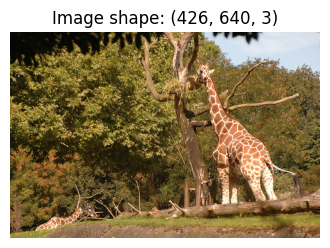

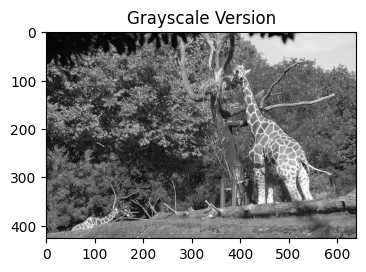

In [ ]:
# current directory started at google drive /content
current_dir = os.getcwd()
print("Current directory:", current_dir)

image = cv2.imread('/content/drive/MyDrive/data/000000000025.jpg')
# Display the image

# 2. Convert BGR (open CV) to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Set the size to 4 inches by 4 inches (change these numbers to make it smaller)
plt.figure(figsize=(4, 4))

# 3. Display the corrected image
plt.imshow(image_rgb)
print(f'\nimage size: {image.shape}\n------------------------------')
plt.title(f'Image shape: {image.shape}')
plt.axis('off') # Optional: hides the x/y axis numbers
plt.show()

# 4. Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. Display with the 'gray' colormap
plt.figure(figsize=(4, 4))
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Version")
plt.show()


type(fig): <class 'matplotlib.figure.Figure'>
i: 0
img_url: /content/drive/MyDrive/data/2persons.jpg
type(img): <class 'numpy.ndarray'>
img.shape: (720, 1280, 3)

0: 384x640 4 persons, 313.5ms
Speed: 12.6ms preprocess, 313.5ms inference, 36.9ms postprocess per image at shape (1, 3, 384, 640)
Results type: <class 'list'>
Results len: 1
result.boxes.cls: tensor([0., 0., 0., 0.])
result.boxes.conf: tensor([0.8913, 0.8766, 0.5905, 0.3323])
class_names: ['person', 'person', 'person', 'person']
type(class_names): <class 'list'>
i: 1
img_url: /content/drive/MyDrive/data/000000000077.jpg
type(img): <class 'numpy.ndarray'>
img.shape: (375, 500, 3)

0: 480x640 3 persons, 1 skateboard, 167.7ms
Speed: 3.3ms preprocess, 167.7ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Results type: <class 'list'>
Results len: 1
result.boxes.cls: tensor([ 0.,  0.,  0., 36.])
result.boxes.conf: tensor([0.8870, 0.8543, 0.8509, 0.3378])
class_names: ['person', 'person', 'person', 'skateboard']
t

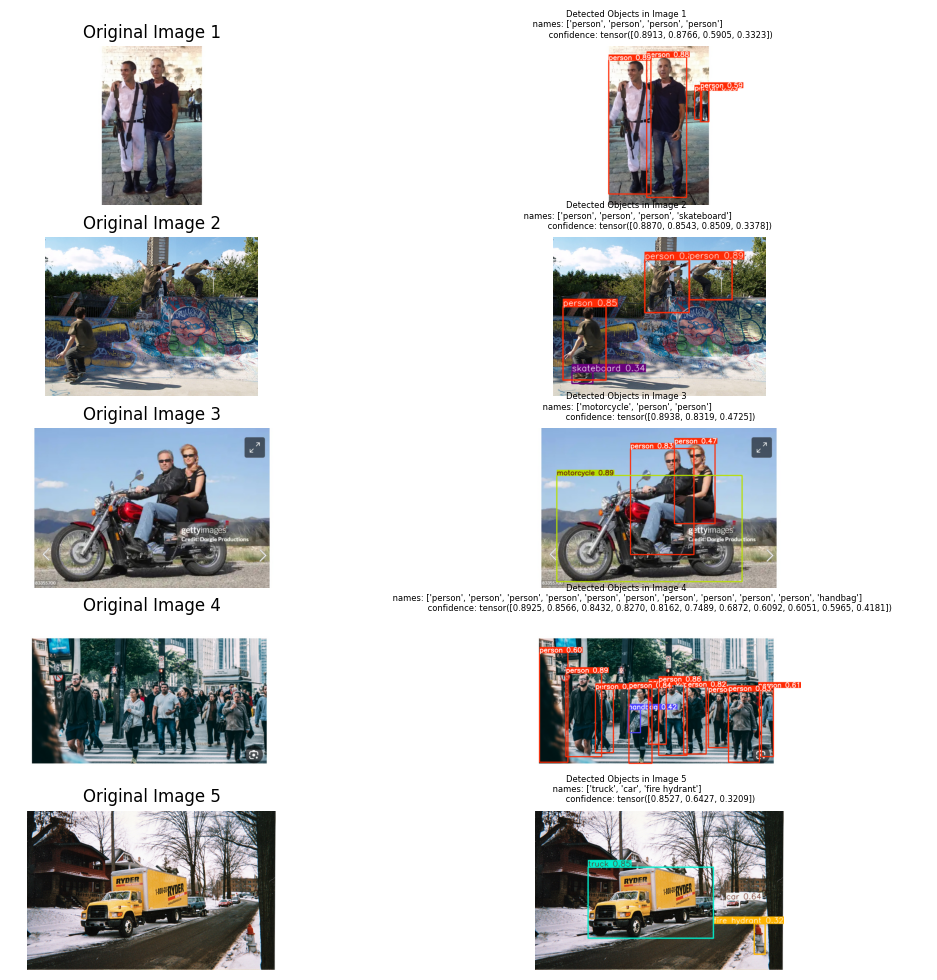

In [ ]:
# URLs of two images from the COCO dataset
coco_images1 = [
    '/content/drive/MyDrive/Data/coaster_messy_3_16.jpg',
    '/content/drive/MyDrive/Data/000000147328.jpg',
    '/content/drive/MyDrive/Data/coaster_messy_3_18.jpg',
    '/content/drive/MyDrive/Data/twopersons.jpg'
]
# MyDrive/data images

coco_images = [
     '/content/drive/MyDrive/data/2persons.jpg','/content/drive/MyDrive/data/000000000077.jpg',
     '/content/drive/MyDrive/data/motor_person.jpg', '/content/drive/MyDrive/data/pedestrains.jpg',
     '/content/drive/MyDrive/data/000000149364.jpg'
]

# display 2 images
#-----------------------------------------
# Functions to download and load an image - with  Open-CV - suitable for one image
def load_image1(url):
    img = cv2.imread(cv2.samples.findFile(url))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img
# suitable for the training / testing when loading batches
def load_image(url):
  img = plt.imread(url) #create numpy array
  return img

num_images = len(coco_images)
# Display original and annotated images
# return tupple of 2 objects for the use of matplotlib
# fig is figure object of the entire plot
# axs is array of numbers of subplots axs[0,0] for example is the first subplot
#-------------------------------------------------------------------------------
rows = num_images
columns = 2
fig, axs = plt.subplots(rows, columns, figsize=(12, 12))

#print(f'type(axs.shape): {type(axs.shape)}')#numpy array
#print(f'type(axs[0,0]): {type(axs[0,0])}') #matplotlib object
print(f'type(fig): {type(fig)}')

for i, img_url in enumerate(coco_images):
    # Load image
    print(f'i: {i}')
    print(f'img_url: {img_url}')

    img = load_image(img_url)
    print(f'type(img): {type(img)}')
    print(f'img.shape: {img.shape}')  # Print the shape of the image
    # Display the original image - image created from the numpy array of pixels
    axs[i, 0].imshow(img)
    axs[i, 0].set_title(f"Original Image {i+1}")
    #no frame around the image
    axs[i, 0].axis('off')

    #---------------------------
    # Perform object detection
    #---------------------------
    results = model(img)


    # Get the image with bounding boxes
    #----------------------------------
    annotated_img = results[0].plot()
    print(f'Results type: {type(results)}')
    print(f'Results len: {len(results)}')

    ''' extracting information from results '''
    '''
    for result in results:
      #print(f'result: {result}')
      print(f'type(result): {type(result)}')
      #print(f'result.boxes: {result.boxes}')
      print(f'result.boxes.cls: {result.boxes.cls}')
      print(f'result.boxes.conf: {result.boxes.conf}')
      #print(f'result.boxes.xyxy: {results.names[result.boxes.cls]}')
      class_indices = result.boxes.cls
      class_names = [result.names[int(idx)] for idx in class_indices]
      print(f'class_names: {class_names}')
'''
    print(f'result.boxes.cls: {results[0].boxes.cls}')
    print(f'result.boxes.conf: {results[0].boxes.conf}')
    class_conf = results[0].boxes.conf
    class_indices = results[0].boxes.cls
    class_names = [results[0].names[int(idx)] for idx in class_indices]
    print(f'class_names: {class_names}')
    print(f'type(class_names): {type(class_names)}')

    # Display the image with detections
    #axs[i, 1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axs[i, 1].imshow(annotated_img)
    axs[i, 1].set_title(f"Detected Objects in Image {i+1} \
                        \n names: {class_names} \
                        \n confidence: {class_conf}", fontsize=6, loc='center')
    axs[i, 1].axis('off')

plt.show()

# Plot performance metrics
#results.plot()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


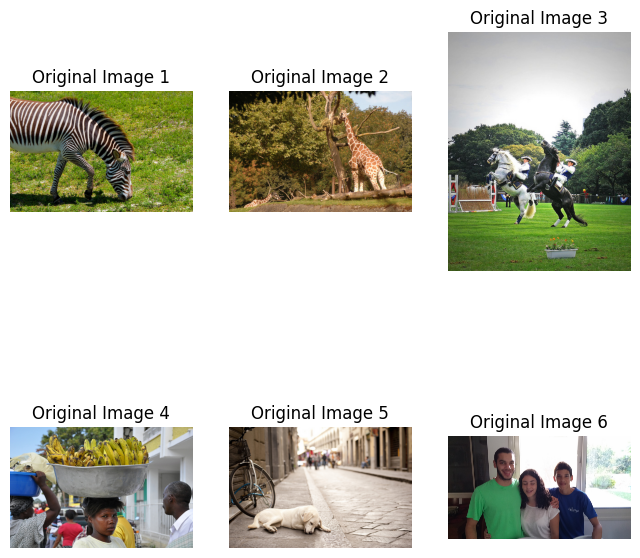


0: 448x640 1 zebra, 234.2ms
Speed: 4.2ms preprocess, 234.2ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 giraffe, 226.2ms
Speed: 4.0ms preprocess, 226.2ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

0: 640x512 2 persons, 2 horses, 1 potted plant, 268.0ms
Speed: 7.5ms preprocess, 268.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 512)

0: 448x640 6 persons, 219.4ms
Speed: 7.3ms preprocess, 219.4ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 3 persons, 1 bicycle, 1 dog, 234.3ms
Speed: 4.2ms preprocess, 234.3ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

0: 384x640 3 persons, 201.2ms
Speed: 4.5ms preprocess, 201.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


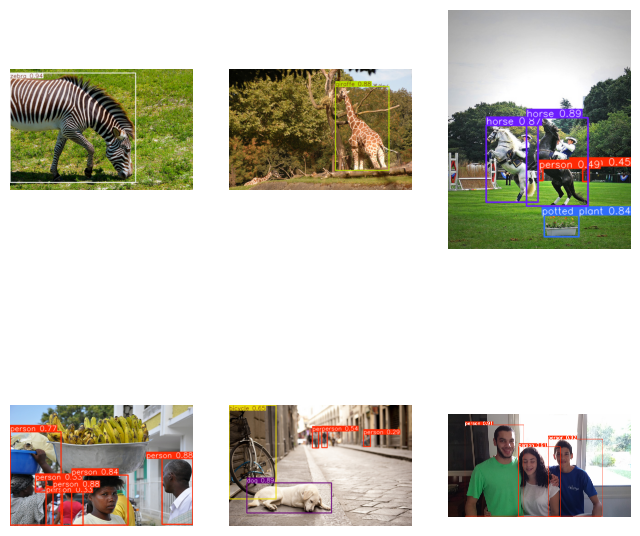

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load YOLOv8n model from Ultralytics
model = YOLO('yolov8n.pt')

# URLs of images from the COCO dataset (more can be added as needed)
coco_images = [
    '/content/drive/MyDrive/data/000000000034.jpg',
     '/content/drive/MyDrive/data/000000000025.jpg',
     '/content/drive/MyDrive/data/000000000049.jpg', '/content/drive/MyDrive/data/000000281563.jpg',
    '/content/drive/MyDrive/data/000000000074.jpg',
    '/content/drive/MyDrive/data/20151025_071652.jpg'
]
#num of images to work on
#-------------------------
num_images = 6
# Function to load an image from a URL
def load_image(url):
    img = cv2.imread(cv2.samples.findFile(url))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# Main function to display images before and after YOLO
def display_images_with_yolo(num_images):
    if num_images > len(coco_images):
        print(f"Number of images requested ({num_images}) exceeds the available images ({len(coco_images)}).")
        num_images = len(coco_images)

    # Display original images
    fig, axs = plt.subplots(2, int(num_images/2), figsize=(8,8))  # Adjusting the grid size based on number of images

    for i in range(num_images):
        img = load_image(coco_images[i])  # Load the image

        axs[int(i // (num_images/2)), int(i % (num_images/2))].imshow(img)  # Display the image
        axs[int(i // (num_images/2)), int(i % (num_images/2))].set_title(f"Original Image {i+1}")  # Set a title for the subplot
        axs[int(i // (num_images/2)), int(i % (num_images/2))].axis('off')  # Hide the axes for a cleaner look

    plt.show()

    # Perform object detection and display images with bounding boxes
    # Adjusting the grid size based on number of images
    fig, axs = plt.subplots(2, int(num_images/2), figsize=(8,8))


    for i in range(num_images):
        img = load_image(coco_images[i])  # Load the image

        # Perform object detection
        results = model(img)

        # Get the image with bounding boxes
        annotated_img = results[0].plot()

        # Display the image with detections
        #axs[int(i // (num_images/2)), int(i % (num_images/2))].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
        axs[int(i // (num_images/2)), int(i % (num_images/2))].imshow(annotated_img)
        #axs[int(i // (num_images/2)), int(i % (num_images/2))].set_title(f"Detected Objects in Image {i+1}")
        axs[int(i // (num_images/2)), int(i % (num_images/2))].axis('off')  # Hide the axes for a cleaner look

    plt.show()

# Example usage: specify the number of images you want to process
display_images_with_yolo(num_images)  # Change the number to display a different number of images